In [1]:
from lappy import *
import numpy as np
import matplotlib.pyplot as plt

# Basis distribution: Right Trapezoids

How many basis functions should we place at each singular corner?

In [151]:
trap_data = np.load("../results/fb_corner_trap.npz")

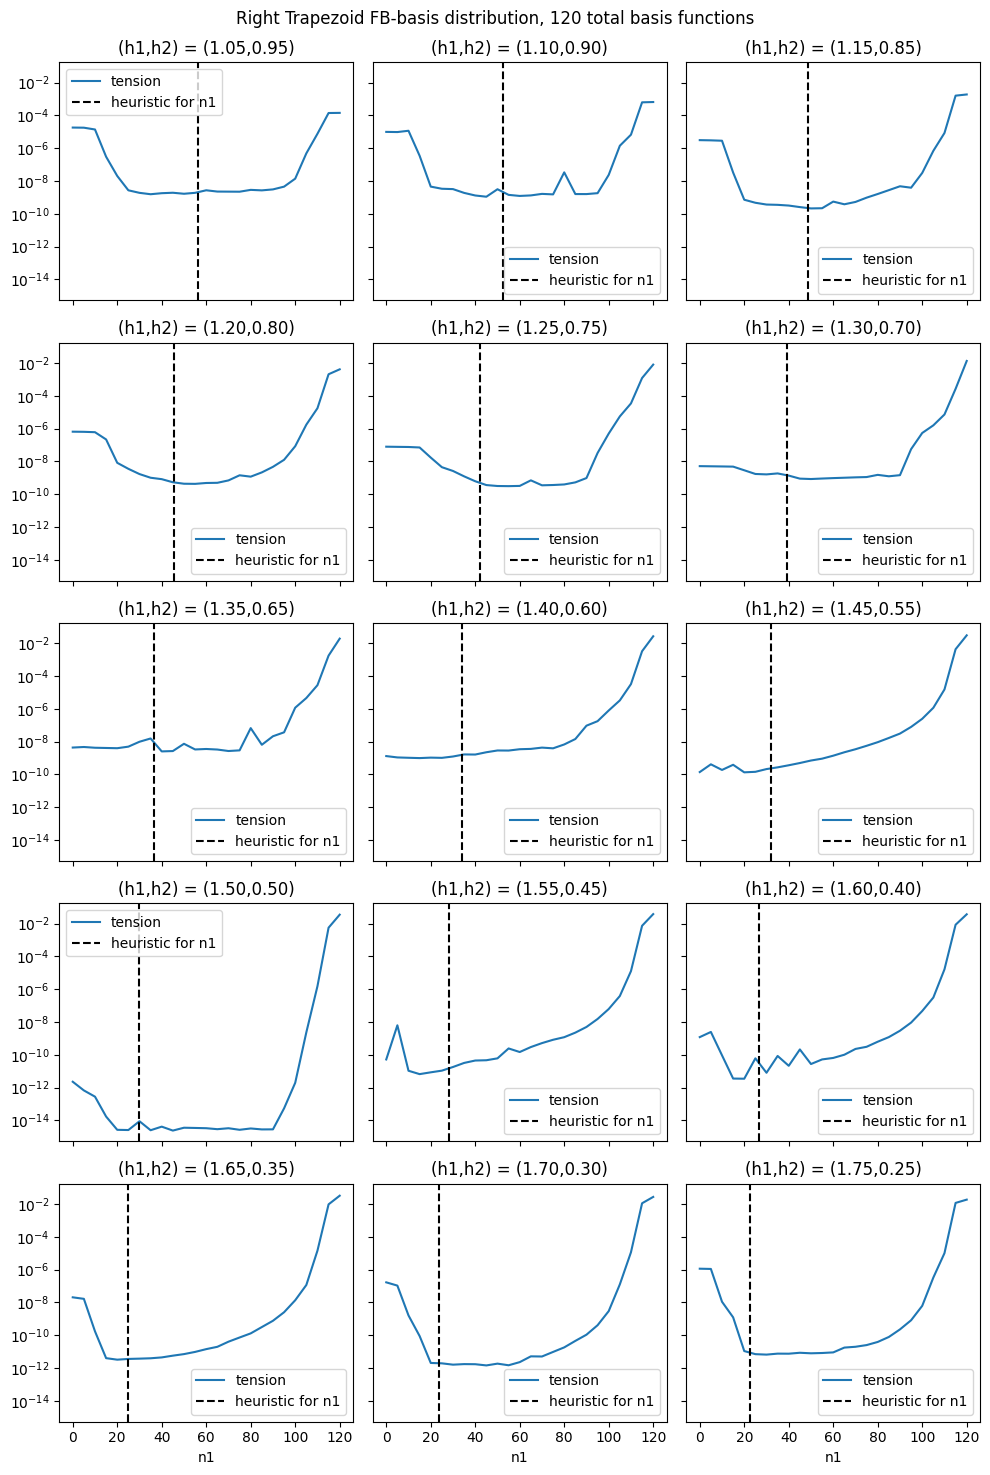

In [175]:
fig, axs = plt.subplots(5,3, figsize=(10,15), sharex=True, sharey=True)
axs = axs.flatten()
for i, h1 in enumerate(trap_data['H1']):
    trap = geometry.right_trapezoid(h1, trap_data['H2'][i])
    int_angles = trap.int_angles
    frac = int_angles[0]/(int_angles[0] + int_angles[-1])
    axs[i].semilogy(trap_data['N1'],trap_data['sigmas'][i], label='tension')
    axs[i].axvline(frac*trap_data['N1'].max(), c='k', linestyle='dashed', label="heuristic for n1")
    axs[i].set_title(f"(h1,h2) = ({h1:.2f},{trap_data['H2'][i]:.2f})")
    if i >= 12:
        axs[i].set_xlabel("n1")
    axs[i].legend()
plt.tight_layout(rect=(0, 0, 1, 0.97))
fig.suptitle("Right Trapezoid FB-basis distribution, 120 total basis functions")
plt.show()

# Basis Distribution: Chevrons

In [178]:
chev_data = np.load("../results/fb_corner_chev.npz")
chev_data['H1'].shape

(15,)

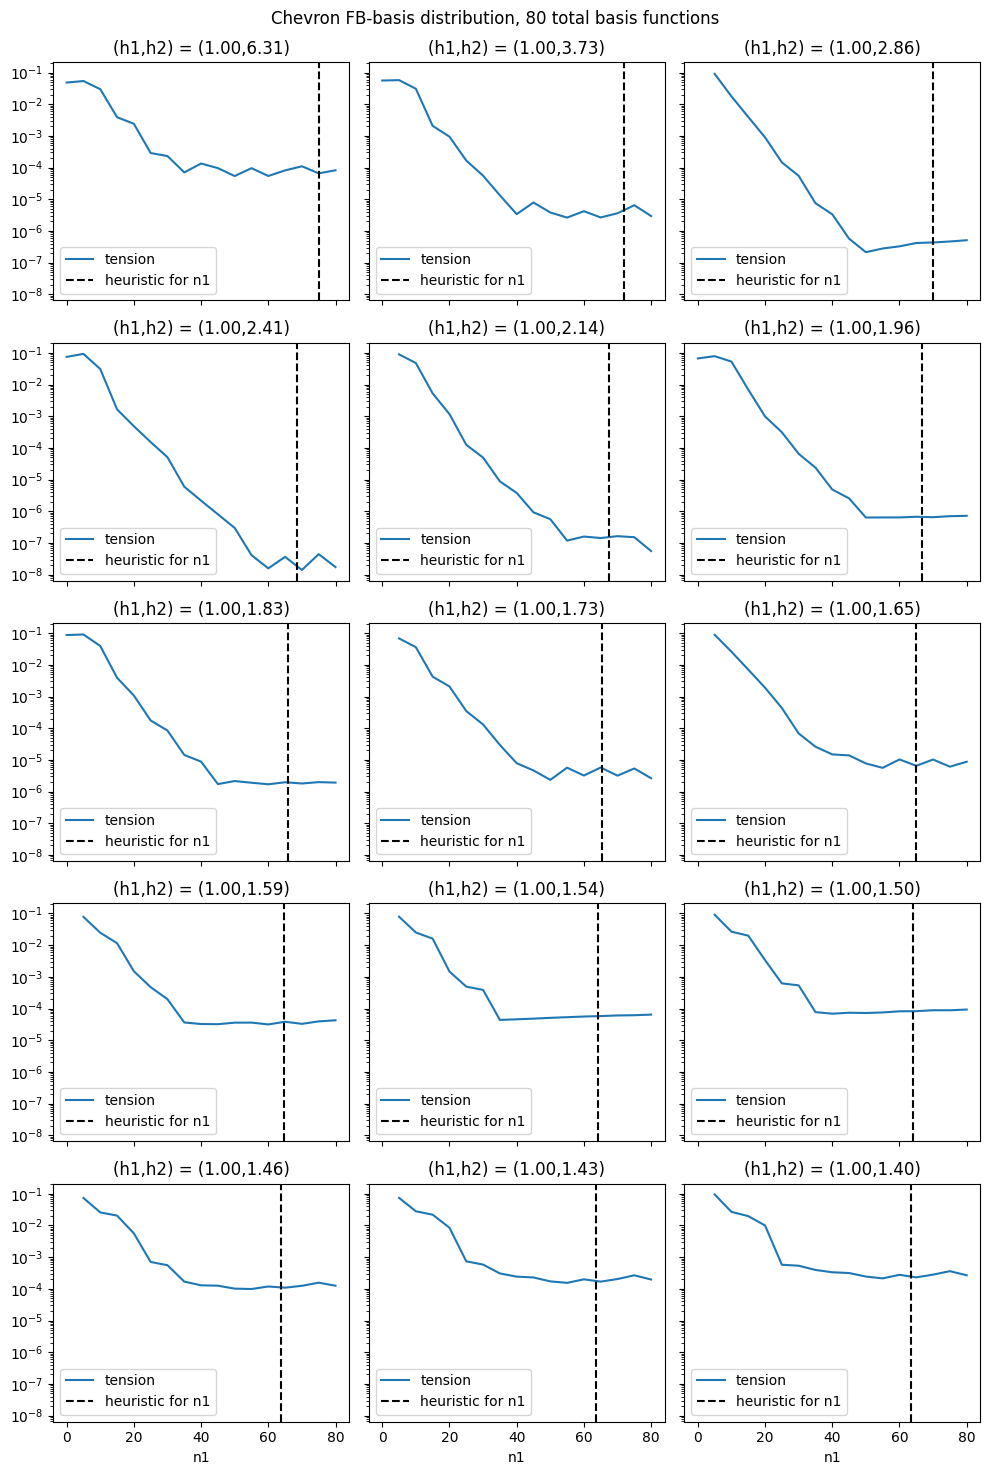

In [179]:
fig, axs = plt.subplots(5,3, figsize=(10,15), sharex=True, sharey=True)
axs = axs.flatten()
for i, h1 in enumerate(chev_data['H1']):
    trap = geometry.chevron(h1, chev_data['H2'][i])
    int_angles = trap.int_angles
    frac = int_angles[1]/(int_angles[1] + int_angles[3])
    axs[i].semilogy(chev_data['N1'],chev_data['sigmas'][i], label='tension')
    axs[i].axvline(frac*chev_data['N1'].max(), c='k', linestyle='dashed', label="heuristic for n1")
    axs[i].set_title(f"(h1,h2) = ({h1:.2f},{chev_data['H2'][i]:.2f})")
    if i >= 12:
        axs[i].set_xlabel("n1")
    axs[i].legend()
plt.tight_layout(rect=(0, 0, 1, 0.97))
fig.suptitle("Chevron FB-basis distribution, 80 total basis functions")
plt.show()

# Four placement strategies

In [2]:
lshape_data = np.load('../results/fb_corner_lshape.npz')
gww1_data = np.load('../results/fb_corner_gww1.npz')
gww2_data = np.load('../results/fb_corner_gww2.npz')
chev_7_data = np.load('../results/fb_corner_chev_7.npz')

def plot_sigmas(data, name):
    fig, ax = plt.subplots()
    plt.semilogy(data['N'], data['sigmas'][0], label='uniform')
    plt.semilogy(data['N'], data['sigmas'][1], label='weighted')
    plt.semilogy(data['N'], data['sigmas'][2], label='singular_uniform')
    plt.semilogy(data['N'], data['sigmas'][3], label='singular_weighted')
    plt.xlabel('n_basis')
    plt.legend()
    plt.title(f"{name} tensions vs. basis size")
    return fig

def plot_errors(data, name, eig1_true):
    fig, ax = plt.subplots()
    plt.semilogy(data['N'], np.abs(data['eigs'][0]-eig1_true)/eig1_true, label='uniform', linestyle='dashed')
    plt.semilogy(data['N'], np.abs(data['eigs'][1]-eig1_true)/eig1_true, label='weighted')
    plt.semilogy(data['N'], np.abs(data['eigs'][2]-eig1_true)/eig1_true, label='singular_uniform', linestyle='dashed')
    plt.semilogy(data['N'], np.abs(data['eigs'][3]-eig1_true)/eig1_true, label='singular_weighted')
    plt.xlabel('n_basis')
    plt.legend()
    plt.title(f"{name} relative error vs basis size")
    return fig

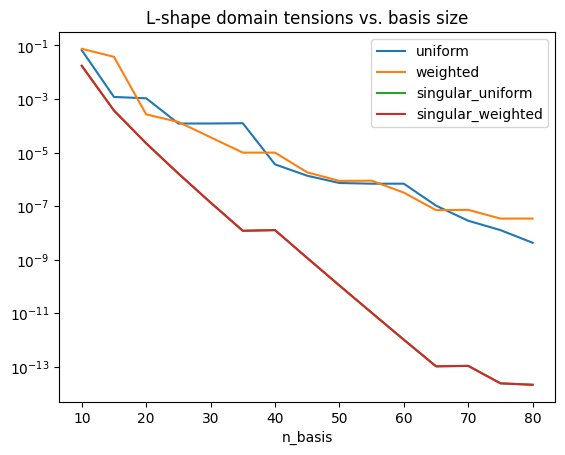

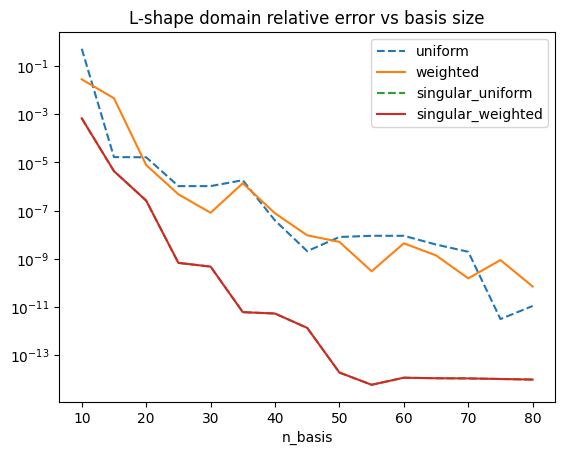

In [191]:
# L-shape domain
fig = plot_sigmas(lshape_data, 'L-shape domain')
plt.show()
fig = plot_errors(lshape_data, 'L-shape domain', reference.L_shape_eigs(1)[0])
plt.show()

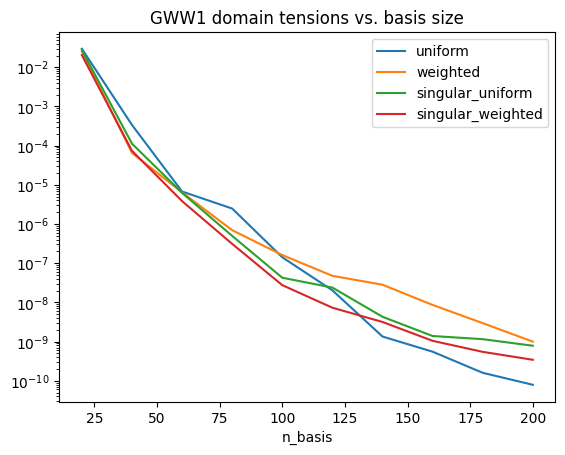

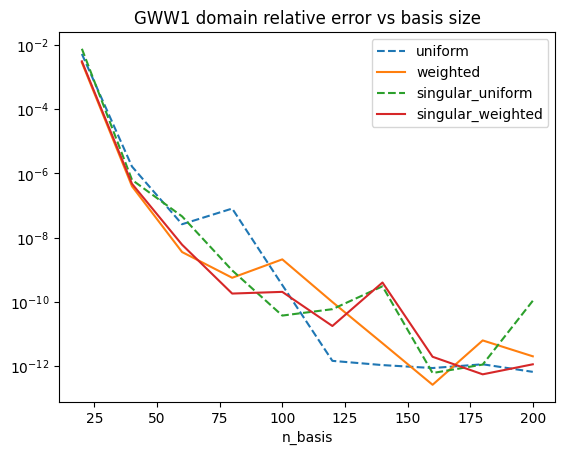

In [192]:
# GWW1 domain
fig = plot_sigmas(gww1_data, 'GWW1 domain')
plt.show()
fig = plot_errors(gww1_data, 'GWW1 domain', reference.gww_eigs(1)[0])
plt.show()

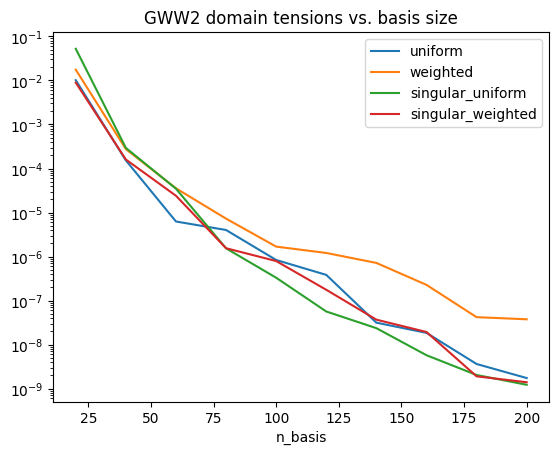

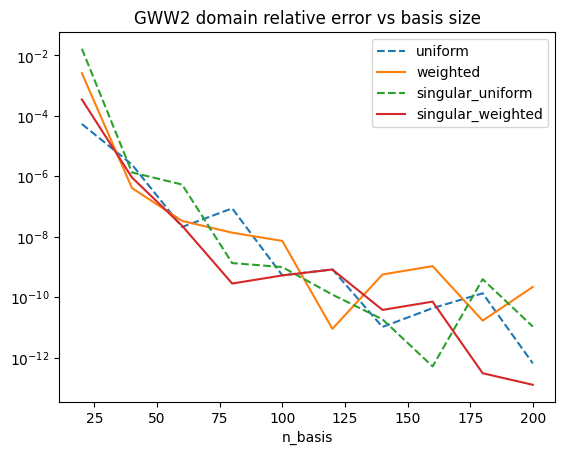

In [193]:
# GWW2 domain
fig = plot_sigmas(gww2_data, 'GWW2 domain')
plt.show()
fig = plot_errors(gww2_data, 'GWW2 domain', reference.gww_eigs(1)[0])
plt.show()

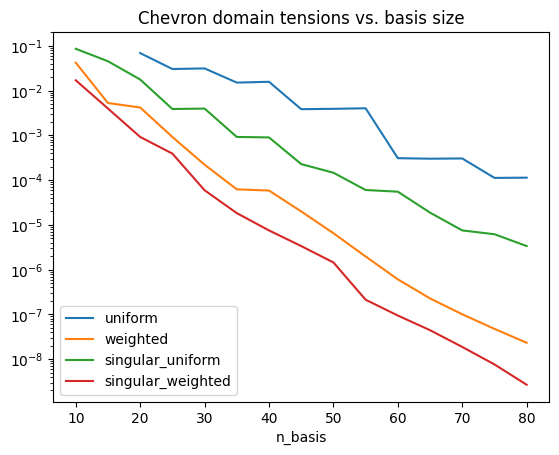

In [194]:
# chevron domain
fig = plot_sigmas(chev_7_data, 'Chevron domain')
plt.show()

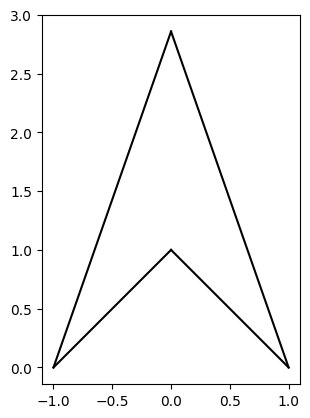

In [185]:
n = 7
reg_chev = geometry.chevron(1, np.tan(np.pi*(n+4)/(4*n)))
reg_chev.plot()
plt.show()

In [141]:
np.pi/reg_chev.int_angles

array([7.        , 0.66666667, 7.        , 4.66666667])

In [158]:
reg_chev.vertices

array([-1.+0.j        ,  0.+1.j        ,  1.+0.j        ,  0.+2.85783581j])

In [177]:
N = np.arange(1,21)
for n in N:
    h2 = np.tan(np.pi*(n+4)/(4*n))
    print(n, h2)

1 0.9999999999999997
2 -1.0000000000000002
3 -3.7320508075688794
4 1.633123935319537e+16
5 6.313751514675041
6 3.7320508075688776
7 2.857835809272378
8 2.4142135623730945
9 2.1445069205095586
10 1.9626105055051506
11 1.8313632660426111
12 1.7320508075688767
13 1.6542020491229108
14 1.5914908829822705
15 1.5398649638145825
16 1.496605762665489
17 1.4598200603321843
18 1.428148006742114
19 1.4005871438998043
20 1.3763819204711731


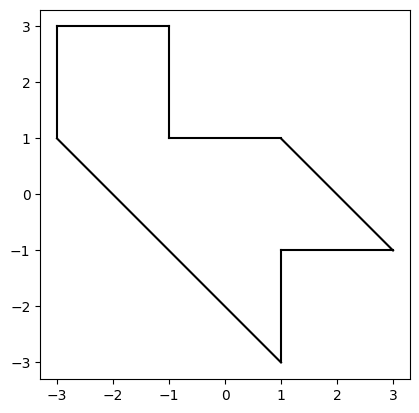

In [186]:
geometry.GWW2().plot()
plt.show()